# Task Data Analysis Notebook

This notebook loads task run stats from `./.pm` and gives a quick view of completion rates, validation behavior, timings, and common failure patterns.

In [2]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
plt.style.use("ggplot")

In [3]:
candidate_dirs = [
    Path.cwd(),
    Path.cwd() / "./.pm",
    Path.cwd().parent / "./.pm",
]

stats_dir = None
stat_files = []
for d in candidate_dirs:
    if d.is_dir():
        files = sorted(d.glob("*-stats.json"))
        if files:
            stats_dir = d
            stat_files = files
            break

print(f"Working directory: {Path.cwd()}")
print(f"Using stats directory: {stats_dir}")
print(f"Found {len(stat_files)} stats file(s).")
stat_files

Working directory: /home/robino/Projects/Go/LazyPM/notebooks
Using stats directory: /home/robino/Projects/Go/LazyPM/.pm
Found 1 stats file(s).


[PosixPath('/home/robino/Projects/Go/LazyPM/.pm/coding-task-stats.json')]

In [4]:
datasets = []
for file in stat_files:
    with file.open() as f:
        data = json.load(f)
    data["_file"] = file.name
    datasets.append(data)

print(f"Loaded {len(datasets)} task dataset(s).")

Loaded 1 task dataset(s).


In [5]:
summary_rows = []
run_rows = []
log_rows = []

for ds in datasets:
    task_name = ds.get("task_name")
    file_name = ds.get("_file")

    summary = ds.get("summary", {}).copy()
    summary.update({"task_name": task_name, "file": file_name})
    summary_rows.append(summary)

    for run in ds.get("runs", []):
        row = run.copy()
        row.update({"task_name": task_name, "file": file_name})
        run_rows.append(row)

        for log in run.get("logs", []):
            lrow = log.copy()
            lrow.update({
                "task_name": task_name,
                "file": file_name,
                "run_id": run.get("run_id"),
                "run_completed": run.get("completed"),
            })
            log_rows.append(lrow)

summary_df = pd.DataFrame(summary_rows)
runs_df = pd.DataFrame(run_rows)
logs_df = pd.DataFrame(log_rows)

for col in ["updated_at", "first_run_started_at", "last_run_started_at", "last_run_ended_at"]:
    if col in summary_df.columns:
        summary_df[col] = pd.to_datetime(summary_df[col], errors="coerce")

for col in ["started_at", "ended_at"]:
    if col in runs_df.columns:
        runs_df[col] = pd.to_datetime(runs_df[col], errors="coerce")

if "timestamp" in logs_df.columns:
    logs_df["timestamp"] = pd.to_datetime(logs_df["timestamp"], errors="coerce")

summary_df.shape, runs_df.shape, logs_df.shape

((1, 19), (19, 18), (2263, 12))

## Task-level summary

In [6]:
summary_cols = [
    "task_name",
    "total_runs",
    "completed_runs",
    "incomplete_runs",
    "average_duration_ms",
    "validation_attempts",
    "validation_successes",
    "validation_failures",
    "total_user_actions",
]

summary_view = summary_df.reindex(columns=summary_cols).copy()

if not summary_view.empty:
    total_runs_nonzero = summary_view["total_runs"].replace({0: pd.NA})
    summary_view["completion_rate_pct"] = (summary_view["completed_runs"] / total_runs_nonzero * 100).round(1)
    summary_view["avg_duration_s"] = (summary_view["average_duration_ms"] / 1000).round(2)

summary_view.sort_values("completion_rate_pct", ascending=False)

,task_name,total_runs,completed_runs,incomplete_runs,average_duration_ms,validation_attempts,validation_successes,validation_failures,total_user_actions,completion_rate_pct,avg_duration_s
0,Coding Task,19,1,18,71081,343,1,342,59,5.3,71.08


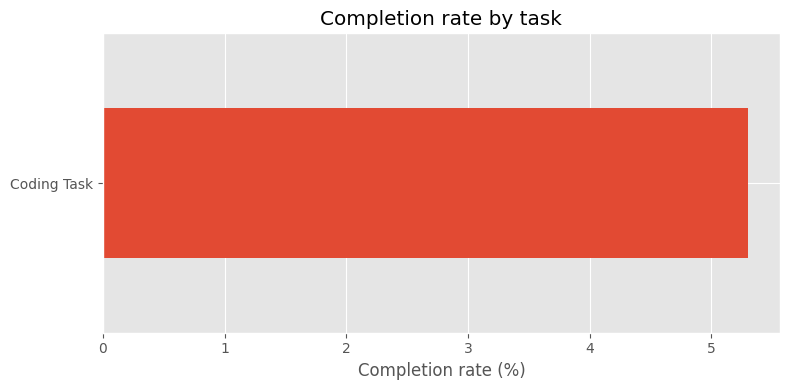

In [7]:
if not summary_view.empty and summary_view["completion_rate_pct"].notna().any():
    plot_df = summary_view[["task_name", "completion_rate_pct"]].sort_values("completion_rate_pct")
    ax = plot_df.plot(kind="barh", x="task_name", y="completion_rate_pct", legend=False, figsize=(8, 4))
    ax.set_xlabel("Completion rate (%)")
    ax.set_ylabel("")
    ax.set_title("Completion rate by task")
    plt.tight_layout()
else:
    print("No summary data available for plotting.")

## Run-level diagnostics

In [8]:
run_cols = [
    "task_name",
    "run_id",
    "interface_type",
    "completed",
    "duration_ms",
    "validation_attempts",
    "validation_successes",
    "validation_failures",
    "questionnaire_completed",
]

runs_view = runs_df.reindex(columns=run_cols).copy()
if "duration_ms" in runs_view.columns:
    runs_view["duration_s"] = (runs_view["duration_ms"] / 1000).round(2)

runs_view.sort_values(["task_name", "run_id"]).head(20)

,task_name,run_id,interface_type,completed,duration_ms,validation_attempts,validation_successes,validation_failures,questionnaire_completed,duration_s
0,Coding Task,1,web,True,90143,84,1,83,True,90.14
1,Coding Task,2,repl,False,28458,0,0,0,False,28.46
2,Coding Task,3,repl,False,10512,0,0,0,False,10.51
3,Coding Task,4,repl,False,87329,78,0,78,True,87.33
4,Coding Task,5,repl,False,41714,40,0,40,True,41.71
5,Coding Task,6,repl,False,54939,53,0,53,True,54.94
6,Coding Task,7,repl,False,39626,38,0,38,True,39.63
7,Coding Task,8,repl,False,48160,46,0,46,True,48.16
8,Coding Task,9,repl,False,11927,2,0,2,True,11.93
9,Coding Task,10,repl,False,258557,2,0,2,True,258.56


In [9]:
if not runs_df.empty and {"task_name", "run_id", "completed", "duration_ms", "validation_attempts"}.issubset(runs_df.columns):
    agg = runs_df.groupby("task_name", dropna=False).agg(
        runs=("run_id", "count"),
        completed_runs=("completed", "sum"),
        avg_duration_s=("duration_ms", lambda s: round(s.mean() / 1000, 2)),
        median_duration_s=("duration_ms", lambda s: round(s.median() / 1000, 2)),
        avg_validation_attempts=("validation_attempts", "mean"),
    )

    agg["completion_rate_pct"] = (agg["completed_runs"] / agg["runs"] * 100).round(1)
    agg["avg_validation_attempts"] = agg["avg_validation_attempts"].round(2)
    display(agg.sort_values("completion_rate_pct", ascending=False))
else:
    print("Not enough run data to build aggregate diagnostics.")

,runs,completed_runs,avg_duration_s,median_duration_s,avg_validation_attempts,completion_rate_pct
task_name,,,,,,
Coding Task,19,1,71.08,48.16,18.05,5.3


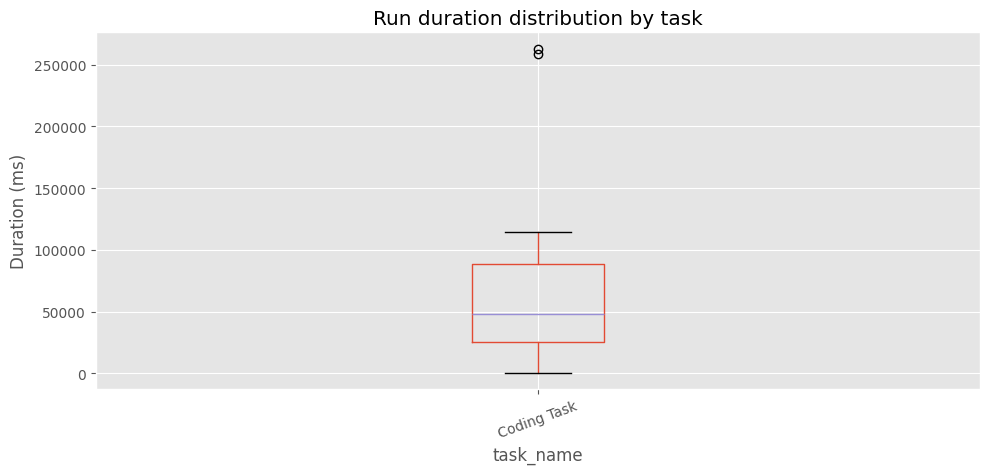

In [10]:
if not runs_df.empty and {"duration_ms", "task_name"}.issubset(runs_df.columns):
    runs_df.boxplot(column="duration_ms", by="task_name", figsize=(10, 5), rot=20)
    plt.title("Run duration distribution by task")
    plt.suptitle("")
    plt.ylabel("Duration (ms)")
    plt.tight_layout()
else:
    print("No run duration data available for boxplot.")

## Validation check failure hotspots

In [11]:
if not logs_df.empty and {"action", "result", "task_name", "target"}.issubset(logs_df.columns):
    validation_checks = logs_df[(logs_df["action"] == "validate_check") & (logs_df["result"] == "failed")].copy()

    if not validation_checks.empty:
        failed_by_target = (
            validation_checks
            .groupby(["task_name", "target"], dropna=False)
            .size()
            .reset_index(name="failed_count")
            .sort_values(["task_name", "failed_count"], ascending=[True, False])
        )
        display(failed_by_target.groupby("task_name", dropna=False).head(10))
    else:
        print("No failed validation checks found.")
else:
    print("No validation logs available for failure hotspot analysis.")

,task_name,target,failed_count
8,Coding Task,The original issue should be assigned to 'Me'....,274
4,Coding Task,No new issues created,273
5,Coding Task,No new issues created. Please create an issue ...,273
10,Coding Task,The original issue should be marked as In Prog...,255
6,Coding Task,The go.mod file should still contain the old v...,57
0,Coding Task,"Issue should be assigned to 'Me', but was assi...",39
2,Coding Task,Issue should be set to Closed once the work is...,39
1,Coding Task,Issue should be marked as in-progress when wor...,30
3,Coding Task,Issue title does not match the expected value ...,30
7,Coding Task,The original issue should be assigned to 'Me'.,4


,task_name,run_id,attempt_count
0,Coding Task,1,84
1,Coding Task,4,78
2,Coding Task,5,40
3,Coding Task,6,53
4,Coding Task,7,38
5,Coding Task,8,46
6,Coding Task,9,2
7,Coding Task,10,2


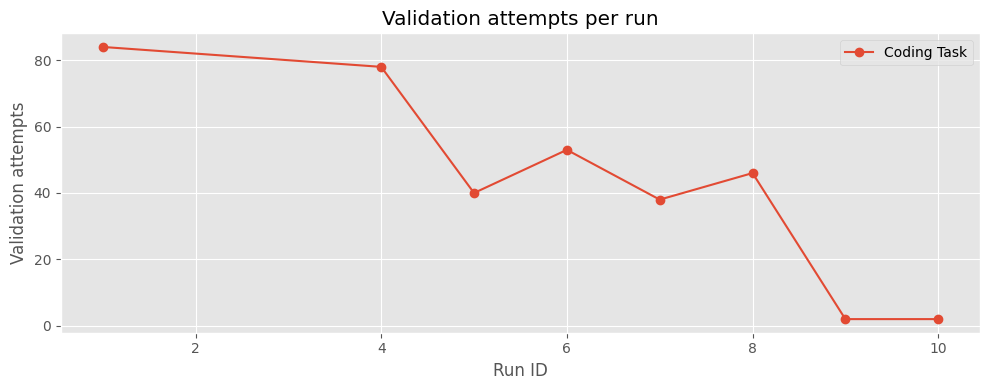

In [12]:
if not logs_df.empty and {"action", "task_name", "run_id"}.issubset(logs_df.columns):
    attempt_logs = logs_df[logs_df["action"] == "validate_attempt"].copy()

    if not attempt_logs.empty:
        attempts_per_run = (
            attempt_logs
            .groupby(["task_name", "run_id"], dropna=False)
            .size()
            .reset_index(name="attempt_count")
            .sort_values(["task_name", "run_id"])
        )

        display(attempts_per_run.head(30))

        fig, ax = plt.subplots(figsize=(10, 4))
        for task_name, g in attempts_per_run.groupby("task_name"):
            ax.plot(g["run_id"], g["attempt_count"], marker="o", label=task_name)

        ax.set_title("Validation attempts per run")
        ax.set_xlabel("Run ID")
        ax.set_ylabel("Validation attempts")
        ax.legend()
        plt.tight_layout()
    else:
        print("No validation attempt logs found.")
else:
    print("No logs available for attempt trend analysis.")

## User action endpoint activity

In [13]:
if not logs_df.empty and {"level", "task_name", "target"}.issubset(logs_df.columns):
    user_actions = logs_df[logs_df["level"] == "user_action"].copy()

    if not user_actions.empty:
        endpoint_counts = (
            user_actions
            .groupby(["task_name", "target"], dropna=False)
            .size()
            .reset_index(name="count")
            .sort_values(["task_name", "count"], ascending=[True, False])
        )

        display(endpoint_counts.groupby("task_name", dropna=False).head(15))
    else:
        print("No user_action logs found.")
else:
    print("No logs available for endpoint activity analysis.")

,task_name,target,count
10,Coding Task,NaN,35
0,Coding Task,GET /,9
5,Coding Task,GET /status/modal,5
3,Coding Task,GET /issues/pm-2vr/edit,2
6,Coding Task,PATCH /issues/pm-2vr,2
1,Coding Task,GET /issues/create,1
2,Coding Task,GET /issues/pm-2vr/assignee,1
4,Coding Task,GET /issues/pm-c9p/assignee,1
7,Coding Task,PATCH /issues/pm-2vr/assignee,1
8,Coding Task,PATCH /issues/pm-c9p/assignee,1


## Quick filters for ad-hoc debugging

In [14]:
# Example: inspect one task and one run.
if not runs_df.empty and {"task_name", "run_id"}.issubset(runs_df.columns):
    task = runs_df["task_name"].iloc[0]
    run_id = 1

    print(f"Task: {task}, run_id: {run_id}")
    display(runs_df[(runs_df["task_name"] == task) & (runs_df["run_id"] == run_id)])

    if not logs_df.empty and {"task_name", "run_id"}.issubset(logs_df.columns):
        display(logs_df[(logs_df["task_name"] == task) & (logs_df["run_id"] == run_id)].head(50))
else:
    print("No run data available.")

Task: Coding Task, run_id: 1


,run_id,task_name,interface_type,started_at,ended_at,duration_ms,completed,validation_attempts,validation_successes,validation_failures,validation_checks_passed,validation_checks_failed,questionnaire_completed,questionnaire_user_quit,questionnaire_answers,logs,file,error
0,1,Coding Task,web,2026-03-04 15:11:56.497145550+01:00,2026-03-04 15:13:26.641005636+01:00,90143,True,84,1,83,499,242,True,False,"{'final_confirmation': None, 'task_completed':...",[{'timestamp': '2026-03-04T15:11:56.497159847+...,coding-task-stats.json,NaN


,timestamp,level,message,source,action,result,task_name,file,run_id,run_completed,target,attempt
0,2026-03-04 15:11:56.497159847+01:00,info,task run started,system,task_run_started,ok,Coding Task,coding-task-stats.json,1,True,NaN,NaN
1,2026-03-04 15:11:57.463612409+01:00,user_action,"{""source"":""web"",""action"":""request"",""target"":""G...",web,request,ok,Coding Task,coding-task-stats.json,1,True,GET /,NaN
2,2026-03-04 15:11:58.318154048+01:00,validation,validation attempt 1,system,validate_attempt,failed,Coding Task,coding-task-stats.json,1,True,NaN,1.0
3,2026-03-04 15:11:58.318199703+01:00,validation,validation check: The original issue should be...,system,validate_check,failed,Coding Task,coding-task-stats.json,1,True,The original issue should be assigned to 'Me'....,1.0
4,2026-03-04 15:11:58.318212096+01:00,validation,validation check: No new issues created. Pleas...,system,validate_check,failed,Coding Task,coding-task-stats.json,1,True,No new issues created. Please create an issue ...,1.0
5,2026-03-04 15:11:58.318221323+01:00,validation,validation check: No new issues created,system,validate_check,failed,Coding Task,coding-task-stats.json,1,True,No new issues created,1.0
6,2026-03-04 15:11:59.317079434+01:00,validation,validation attempt 2,system,validate_attempt,failed,Coding Task,coding-task-stats.json,1,True,NaN,2.0
7,2026-03-04 15:11:59.317145086+01:00,validation,validation check: The original issue should be...,system,validate_check,failed,Coding Task,coding-task-stats.json,1,True,The original issue should be assigned to 'Me'....,2.0
8,2026-03-04 15:11:59.317171636+01:00,validation,validation check: No new issues created. Pleas...,system,validate_check,failed,Coding Task,coding-task-stats.json,1,True,No new issues created. Please create an issue ...,2.0
9,2026-03-04 15:11:59.317194609+01:00,validation,validation check: No new issues created,system,validate_check,failed,Coding Task,coding-task-stats.json,1,True,No new issues created,2.0
